# Assignment 4

Deadline: 30.04.2025 12:00 CET

<Add your name, student-id and emal address>

## Prerequisites: Library imports, data load and initialization of the backtest service

In [1]:
# Standard library imports
import os
import sys
import copy
from typing import Optional

# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   #<Change this path if needed>
src_path = os.path.join(project_root, 'qpmwp-course/src')    #<Change this path if needed>
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import load_data_spi, load_pickle
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.optimization import Optimization, Objective, MeanVariance
from optimization.optimization_data import OptimizationData
from optimization.constraints import Constraints
from backtesting.backtest_item_builder_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder_functions import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
    bibfn_return_series,
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

In [2]:
# Load data
path_to_data = '/home/patsias/QPM/EXERCISE/qpmwp-course/data/'  # <change this to your path to data>

# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{path_to_data}market_data.parquet')

# Instantiate the BacktestData class
# and set the market data and jkp data as attributes
data = BacktestData()
data.market_data = market_data
data.bm_series = load_data_spi(path='../data/')  # <change this if necessary>

In [3]:
# Define rebalancing dates
n_days = 21*3
market_data_dates = market_data.index.get_level_values('date').unique().sort_values(ascending=True)
rebdates = market_data_dates[market_data_dates > '2015-01-01'][::n_days].strftime('%Y-%m-%d').tolist()

In [4]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn = bibfn_selection_gaps,
        width = 252*3,
        n_days = 10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn = bibfn_selection_min_volume,
        width = 252,
        min_volume = 500_000,
        agg_fn = np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn = bibfn_return_series,
        width = 252*3,
        fill_value = 0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn = bibfn_budget_constraint,
        budget = 1,
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn = bibfn_box_constraints,
        upper = 0.1,
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data = data,
    selection_item_builders = selection_item_builders,
    optimization_item_builders = optimization_item_builders,
    rebdates = rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing your its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [5]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            **kwargs,
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return
        self.optimization_data = kwargs.get('optimization_data', None)

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = self.optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        mu = self.expected_return.estimate(X=X, inplace=False)

        self.covmat = covmat
        self.mu = mu

        self.objective = Objective(
            q = mu * -1,
            P = covmat * 2 * 1,
        )
        return None

    def solve(self) -> None:
        max_sharpe_ratio = -np.inf
        for i in range(100):
            self.set_objective(self.optimization_data)
            super().solve()

            weights = pd.Series(self.results['weights']).to_numpy()

            portfolio_return = float(self.mu @ weights)
            portfolio_risk = float(np.sqrt(weights.T @ self.covmat @ weights))

            sharpe_ratio = portfolio_return / portfolio_risk

            max_sharpe_ratio = max(sharpe_ratio, max_sharpe_ratio)

        return None

b) 

(2 points)

Provide a theoretical or empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

In [6]:
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',  # <change this to your preferred solver>
    optimization_data=bs.optimization_data
)
bs.prepare_rebalancing('2015-01-02')
bs.optimization.set_objective(bs.optimization_data)
bs.optimization.solve()
bs.optimization.results

{'weights': {'102': 4.3838507291059954e-08,
  '103': 1.8904605591881708e-08,
  '104': 0.01999997261833539,
  '111': 0.01999996865790603,
  '113': 6.031961211950506e-09,
  '122': 0.019999901550917968,
  '125': 0.0199999432068976,
  '127': 0.019999920812538586,
  '128': 0.019999972651361636,
  '13': 0.019998949063411535,
  '139': 0.019999985637533014,
  '141': 0.019999991411578186,
  '142': 7.41655365133949e-08,
  '148': 0.01999998355150029,
  '149': 2.285133694371424e-08,
  '154': 2.810644175070855e-08,
  '159': 8.359117029009128e-08,
  '161': 2.9801713002153055e-06,
  '169': 0.019999976093723476,
  '175': 0.019996213137347865,
  '176': 0.01999996232363825,
  '177': 9.88665543979409e-09,
  '184': 0.01999992876159636,
  '185': 0.019999896389150847,
  '187': 8.913374005201691e-08,
  '189': 0.01999989033950606,
  '191': 3.107429055064293e-08,
  '197': 0.019999865587787373,
  '2': 5.194904885600572e-08,
  '200': 0.01999996455362763,
  '201': 0.019999984300708373,
  '204': 0.0199999817834111

## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

Calibrate the turnover penalty parameter such that the backtest of the MaxSharpe strategy displays an annual turnover of roughly 100%.

In [18]:
# Update the backtest service with a MaxSharpe optimization object
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',    # <change this to your preferred solver>
    turnover_penalty=0.0001,   # <change this>
    optimization_data=bs.optimization_data
)

# Instantiate the backtest object
bt_ms = Backtest()

# Run the backtest
bt_ms.run(bs = bs)

Rebalancing date: 2015-01-02
Rebalancing date: 2015-04-01
Rebalancing date: 2015-06-29
Rebalancing date: 2015-09-24
Rebalancing date: 2015-12-22
Rebalancing date: 2016-03-18
Rebalancing date: 2016-06-15
Rebalancing date: 2016-09-12
Rebalancing date: 2016-12-08
Rebalancing date: 2017-03-07
Rebalancing date: 2017-06-02
Rebalancing date: 2017-08-30
Rebalancing date: 2017-11-27
Rebalancing date: 2018-02-22
Rebalancing date: 2018-05-22
Rebalancing date: 2018-08-17
Rebalancing date: 2018-11-14
Rebalancing date: 2019-02-11
Rebalancing date: 2019-05-09
Rebalancing date: 2019-08-06
Rebalancing date: 2019-11-01
Rebalancing date: 2020-01-29
Rebalancing date: 2020-04-27
Rebalancing date: 2020-07-23
Rebalancing date: 2020-10-20
Rebalancing date: 2021-01-15
Rebalancing date: 2021-04-14
Rebalancing date: 2021-07-12
Rebalancing date: 2021-10-07
Rebalancing date: 2022-01-04
Rebalancing date: 2022-04-01
Rebalancing date: 2022-06-29
Rebalancing date: 2022-09-26
Rebalancing date: 2022-12-22
Rebalancing da

## 3. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% and variable costs of 0.3%.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


/home/patsias/QPM/EXERCISE/qpmwp-course/src/backtesting/strategy.py:195: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  portf_ret[0] -= varcost[0]
/home/patsias/QPM/EXERCISE/qpmwp-course/src/backtesting/strategy.py:195: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  portf_ret[0] -= varcost[0]


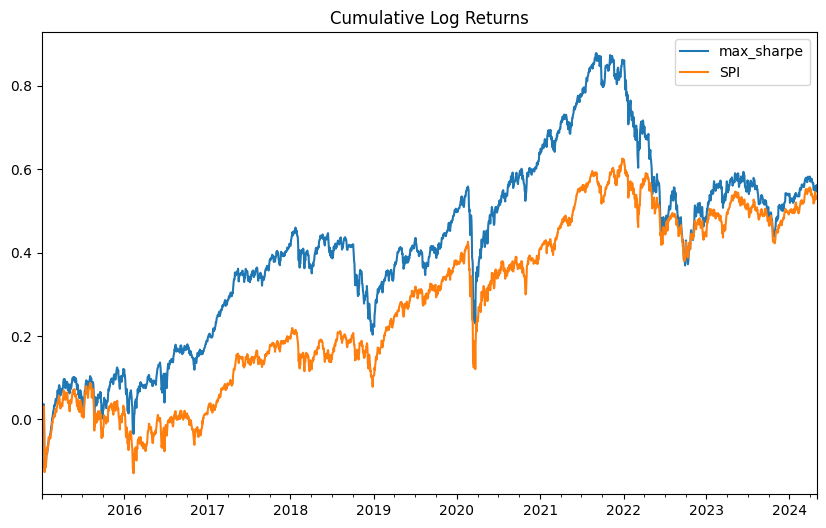

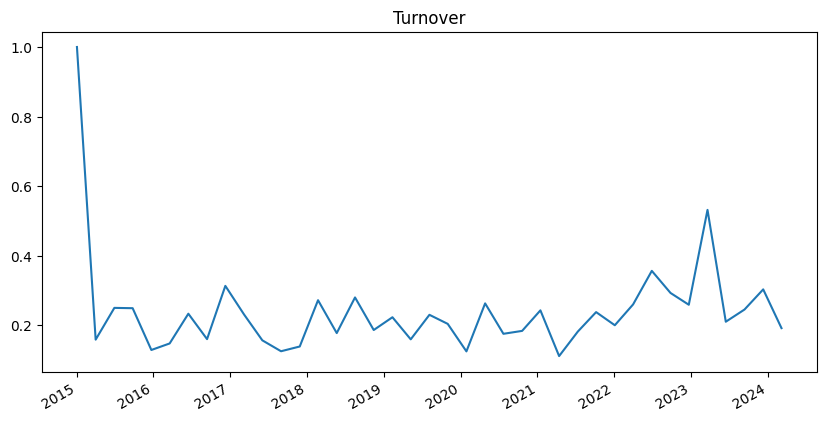

Annualized Turnover: 96.25%


,max_sharpe,SPI
Annual Return,0.110083,0.108449
Cumulative Return,0.739782,0.701100
Annual Volatility,0.156995,0.145690
Sharpe Ratio,0.444434,0.451148
Max Drawdown,-0.398851,-0.263289
Tracking Error,0.075112,0.000000


In [25]:
return_series = bs.data.get_return_series()
sim_ms = bt_ms.strategy.simulate(return_series=return_series, fc=0.01, vc=0.003)

import matplotlib.pyplot as plt

# --- Cumulative Log Returns Plot ---
sim = pd.concat({
    'max_sharpe': sim_ms,
    'SPI': data.bm_series,
}, axis=1).dropna()


cumulative_returns = np.log(1 + sim).cumsum()

plt.figure(figsize=(10, 6))
cumulative_returns.plot(ax=plt.gca(), title='Cumulative Log Returns')
plt.show()

# --- Turnover Plot ---
turnover = bt_ms.strategy.turnover(return_series=return_series, rescale=True)
turnover.index = pd.to_datetime(turnover.index.to_timestamp() if isinstance(turnover.index, pd.PeriodIndex) else turnover.index)

plt.figure(figsize=(10, 5))
turnover.plot(ax=plt.gca(), title='Turnover')
plt.show()

# --- Annualized Turnover ---
rebalances_per_year = 4
annual_turnover = turnover.mean() * rebalances_per_year
print(f"Annualized Turnover: {annual_turnover:.2%}")


# --- Decriptive statistics ---

import empyrical as ep
import pandas as pd

annual_return = {}
cumulative_returns = {}
annual_volatility = {}
sharpe_ratio = {}
max_drawdown = {}
tracking_error = {}
for column in sim.columns:
    # Convert daily returns to price series (cumulative return)
    price_series = np.exp(np.log(1 + sim[column]).cumsum())  
    # Get the final value (cumulative return)
    final_value = price_series.tail(1).values[0]  
    # Calculate the number of years
    num_years = len(sim) / 252  
    # Calculate the CAGR (annualized return)
    cagr = (final_value + 1) ** (1 / num_years) - 1  
    annual_return[column] = cagr

    # annual_return[column] = ep.annual_return(sim[column])
    cumulative_returns[column] = ep.cum_returns(sim[column]).tail(1).values[0]
    annual_volatility[column] = ep.annual_volatility(sim[column])
    sharpe_ratio[column] = ep.sharpe_ratio(sim[column])
    max_drawdown[column] = ep.max_drawdown(sim[column])
    tracking_error[column] = ep.annual_volatility(sim[column] - sim['SPI'])

annual_returns_df = pd.DataFrame(annual_return, index=['Annual Return'])
cumret_df = pd.DataFrame(cumulative_returns, index=['Cumulative Return'])
annual_volatility_df = pd.DataFrame(annual_volatility, index=['Annual Volatility'])
sharpe_df = pd.DataFrame(sharpe_ratio, index=['Sharpe Ratio'])
mdd_df = pd.DataFrame(max_drawdown, index=['Max Drawdown'])
tracking_error_df = pd.DataFrame(tracking_error, index=['Tracking Error'])

performance_table = pd.concat([annual_returns_df, cumret_df, annual_volatility_df, sharpe_df, mdd_df, tracking_error_df])
performance_table
